# LIBRARIES IMPORTATION

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats.mstats import winsorize

import warnings
warnings.filterwarnings("ignore")

In [2]:
pd.set_option("display.max.column", 20)
# Display revenue values in full
pd.options.display.float_format = '{:,.0f}'.format

# DATA IMPORTATION AND PROFILING

In [3]:
customer = pd.read_csv(r"C:\Users\DELL\OIBSIP\DataAnalytics-L1-EDARetailSales\customers.csv")

In [4]:
customer.head()

,customer_id,full_name,age,gender,email,phone,street_address,city,state,zip_code,registration_date,preferred_channel
0,4c30e132-0704-4459-a509-9eddde934977,Mark Johnson,40,Male,mark.johnson@yahoo.com,989.608.3863,819 Johnson Course,Houston,Texas,"29,158",4/25/2024,NaN
1,68bec407-275f-4b5b-9a82-13d02f54626a,Robert Smith,33,Male,smithr@yahoo.com,(518)349-5931x0341,35116 Michael Key Suite 078,Austin,Texas,"16,862",5/30/2021,in-store
2,4466459f-76c8-433c-814e-6d59cb4131fc,Jamie Chavez,42,Female,jchavez@gmail.com,364.583.5030x564,419 Amanda Gardens,Detroit,Michigan,"21,918",12/14/2023,online
3,04c36a25-02f3-462c-92b0-6bf291c57706,Thomas Bradley,53,Male,thomas.bradley@hotmail.com,(332)887-1012x269,7242 Julie Plain Suite 969,Fort Worth,Texas,"52,851",7/11/2022,both
4,e916df3d-c3f5-40b0-8ae2-5d043be88300,Jane Ferrell,32,Female,jane.ferrell@hotmail.com,5484281489,845 Kelly Estate,Atlanta,Georgia,"59,971",9/6/2020,online


In [5]:
cus_df = customer.copy()

In [6]:
cus_df.head()

,customer_id,full_name,age,gender,email,phone,street_address,city,state,zip_code,registration_date,preferred_channel
0,4c30e132-0704-4459-a509-9eddde934977,Mark Johnson,40,Male,mark.johnson@yahoo.com,989.608.3863,819 Johnson Course,Houston,Texas,"29,158",4/25/2024,NaN
1,68bec407-275f-4b5b-9a82-13d02f54626a,Robert Smith,33,Male,smithr@yahoo.com,(518)349-5931x0341,35116 Michael Key Suite 078,Austin,Texas,"16,862",5/30/2021,in-store
2,4466459f-76c8-433c-814e-6d59cb4131fc,Jamie Chavez,42,Female,jchavez@gmail.com,364.583.5030x564,419 Amanda Gardens,Detroit,Michigan,"21,918",12/14/2023,online
3,04c36a25-02f3-462c-92b0-6bf291c57706,Thomas Bradley,53,Male,thomas.bradley@hotmail.com,(332)887-1012x269,7242 Julie Plain Suite 969,Fort Worth,Texas,"52,851",7/11/2022,both
4,e916df3d-c3f5-40b0-8ae2-5d043be88300,Jane Ferrell,32,Female,jane.ferrell@hotmail.com,5484281489,845 Kelly Estate,Atlanta,Georgia,"59,971",9/6/2020,online


In [7]:
cus_df.shape

(5000, 12)

In [8]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        5000 non-null   object 
 1   full_name          4894 non-null   object 
 2   age                4814 non-null   float64
 3   gender             4888 non-null   object 
 4   email              4889 non-null   object 
 5   phone              4814 non-null   object 
 6   street_address     4823 non-null   object 
 7   city               4903 non-null   object 
 8   state              4907 non-null   object 
 9   zip_code           4904 non-null   float64
 10  registration_date  5000 non-null   object 
 11  preferred_channel  4886 non-null   object 
dtypes: float64(2), object(10)
memory usage: 468.9+ KB


After checking details about this dataset, here is what i identified:
1. There are 5,000 enteries and 12 columns.
2. There are missing values in about 10 columns except from customer_id and preferred_channel column.  
3. Mismatched datatype in age, zip code and registration_date columns. Age is an object instead of an integer, registration_date is an object but it's supposed to be a datetime datatype, zip code is suppose to be a string.

# Data Cleaning

In [9]:
duplicate_values = cus_df.duplicated().sum()
duplicate_values

0

In [10]:
missing_values = cus_df.isna().sum()
missing_values

customer_id            0
full_name            106
age                  186
gender               112
email                111
phone                186
street_address       177
city                  97
state                 93
zip_code              96
registration_date      0
preferred_channel    114
dtype: int64

In [11]:
# Dropping the columns that won't be needed for analysis
cus_df.drop(columns = ["full_name", "email", "street_address", "zip_code", "registration_date"], inplace = True)

In [12]:
cus_df["age"].describe()

count   4,814
mean       35
std        11
min        18
25%        27
50%        35
75%        42
max        80
Name: age, dtype: float64

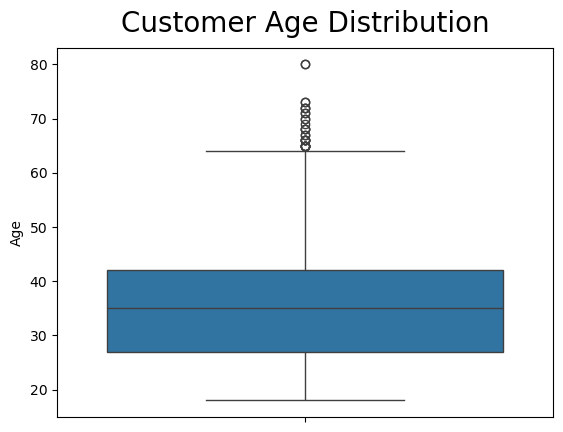

In [13]:
g = sns.boxplot(y = "age", data = cus_df)
g.set_title("Customer Age Distribution", fontsize = 20, y = 1.02)
g.set_ylabel("Age")
plt.show()

Filling missing age with median, since there are outliers and the data is skewed because median don't have an effect on extreme values.

In [14]:
cus_df["age"].fillna(cus_df["age"].median(), inplace = True)

In [15]:
cus_df["age"] = cus_df["age"].astype("int64")

In [16]:
cus_df["gender"].value_counts()

gender
Female               2413
Male                 2297
Non-binary            125
Prefer not to say      53
Name: count, dtype: int64

In [17]:
cus_df["gender"].fillna("Female", inplace = True)

In [18]:
cus_df["city"].unique()

array(['Houston', 'Austin', 'Detroit', 'Fort Worth', 'Atlanta',
       'San Francisco', 'Tempe', 'Tucson', 'New York City', 'Syracuse',
       'Columbus', 'Seattle', 'Macon', 'Arlington', 'Sacramento',
       'Champaign', 'Miami', 'Springfield', 'Toledo', 'Richmond',
       'Orlando', 'Phoenix', 'Trenton', 'Buffalo', 'Greensboro',
       'Rochester', 'Pittsburgh', 'Allentown', 'Savannah', 'Erie',
       'San Diego', 'Lowell', 'Virginia Beach', 'San Antonio',
       'Charlotte', 'Cincinnati', 'Vancouver', 'Philadelphia', 'Albany',
       'Tallahassee', 'Grand Rapids', 'Newark', 'Elizabeth', 'Flint',
       'Tampa', 'Jacksonville', 'Norfolk', 'Lansing', 'Chicago',
       'Los Angeles', 'Harrisburg', 'San Jose', 'Raleigh', 'Alexandria',
       'Tacoma', 'Augusta', 'Mesa', 'Worcester', 'Cambridge', 'Dallas',
       nan, 'Scottsdale', 'Bellevue', 'Spokane', 'Peoria', 'Rockford',
       'Ann Arbor', 'Athens', 'Durham', 'Akron', 'Cleveland',
       'Winston-Salem', 'Boston', 'Paterson', 'Jers

In [19]:
cus_df.dropna(subset = "city", inplace = True)

In [20]:
cus_df["state"].unique()

array(['Texas', 'Michigan', 'Georgia', 'California', 'Arizona',
       'New York', 'Ohio', 'Washington', 'Virginia', 'Illinois',
       'Florida', 'Massachusetts', 'New Jersey', 'North Carolina',
       'Pennsylvania', nan], dtype=object)

In [21]:
cus_df["state"].value_counts()

state
California        859
Texas             634
Florida           529
New York          457
Illinois          290
Pennsylvania      286
Ohio              254
Georgia           243
North Carolina    222
Michigan          205
Virginia          197
New Jersey        165
Washington        162
Arizona           155
Massachusetts     153
Name: count, dtype: int64

In [22]:
cus_df.dropna(subset = "state", inplace = True)

In [23]:
cus_df["preferred_channel"].unique()

array([nan, 'in-store', 'online', 'both'], dtype=object)

In [24]:
cus_df["preferred_channel"].value_counts(normalize = True)

preferred_channel
online     1
both       0
in-store   0
Name: proportion, dtype: float64

In [25]:
cus_df["preferred_channel"].value_counts()

preferred_channel
online      2383
both        1394
in-store     922
Name: count, dtype: int64

In [26]:
cus_df.dropna(subset = "preferred_channel", inplace = True)

### Missing Value Treatment

Missing values were handled based on the type and importance of each variable. **Age (118 missing values)** was filled using the **median**, since Age is numerical and the median is less affected by extreme values. **Gender (112 missing values)** was filled using the **mode**, as it is a categorical variable.

For **City (97), State (93), and Preferred Channel (114)**, the affected rows were dropped because the number of missing records was relatively small and there was no reliable information to determine the correct values. This avoided introducing incorrect or assumed information into the dataset and helped maintain data accuracy.


In [27]:
# First convert phone number to a string.
cus_df["phone"] = cus_df["phone"].astype("string")

In [28]:
# Extract extension
cus_df['extension'] = cus_df['phone'].str.extract(r'[xX](\d+)', expand = False)

In [29]:
# Remove extension
cus_df['phone_clean'] = cus_df['phone'].str.replace(r'[xX]\d+', '', regex = True)

In [30]:
# Remove brackets, spaces, dots, hyphens, +
cus_df['phone_clean'] = cus_df['phone_clean'].str.replace(r'\D', '', regex = True)

In [31]:
# Turn empty strings into missing values
cus_df['phone_clean'] = cus_df['phone_clean'].replace('', pd.NA)

In [32]:
# Validate standard 10-digit numbers
cus_df['phone_valid'] = cus_df['phone_clean'].str.fullmatch(r'\d{10}')

In [33]:
# Handle 11-digit numbers beginning with 1
cus_df.loc[
    cus_df['phone_clean'].str.fullmatch(r'1\d{10}', na = False), 'phone_clean'] = cus_df['phone_clean'].str[1:]

In [34]:
# Handle 13-digit numbers beginning with 001
cus_df.loc[
    cus_df['phone_clean'].str.fullmatch(r'001\d{10}', na = False),'phone_clean'] = cus_df['phone_clean'].str[3:]

In [35]:
# Anything that isn't exactly 10 digits becomes missing
cus_df.loc[
    ~cus_df['phone_clean'].str.fullmatch(r'\d{10}', na = False), 'phone_clean'] = pd.NA

In [36]:
cus_df['phone_clean'].str.len().value_counts(dropna = False)

phone_clean
10      4367
<NA>     332
Name: count, dtype: Int64

In [37]:
cus_df[cus_df['phone_clean'].isna()][['phone', 'phone_clean']]

,phone,phone_clean
7,<NA>,<NA>
37,-11121,<NA>
43,-7004,<NA>
51,<NA>,<NA>
61,<NA>,<NA>
...,...,...
4960,<NA>,<NA>
4962,-9879,<NA>
4967,-6859,<NA>
4984,-5584,<NA>


In [38]:
cus_df['phone_clean'] = cus_df['phone_clean'].str.replace(
    r'(\d{3})(\d{3})(\d{4})', r'\1-\2-\3', regex = True)

This code takes the values in the `phone_clean` column and **reformats 10-digit phone numbers into the `XXX-XXX-XXXX` format**. The regular expression `r'(\d{3})(\d{3})(\d{4})'` splits the phone number into three groups: the first 3 digits, the next 3 digits, and the final 4 digits. Then `r'\1-\2-\3'` puts those groups back together with hyphens between them. For example, `0801234567` would become `080-123-4567`. `regex=True` tells Pandas to treat the first argument as a regular expression.


In [39]:
cus_df['preferred_channel'] = cus_df['preferred_channel'].str.title()
# To convert values to proper case.

In [40]:
cus_df.head()

,customer_id,age,gender,phone,city,state,preferred_channel,extension,phone_clean,phone_valid
1,68bec407-275f-4b5b-9a82-13d02f54626a,33,Male,(518)349-5931x0341,Austin,Texas,In-Store,0341,518-349-5931,True
2,4466459f-76c8-433c-814e-6d59cb4131fc,42,Female,364.583.5030x564,Detroit,Michigan,Online,564,364-583-5030,True
3,04c36a25-02f3-462c-92b0-6bf291c57706,53,Male,(332)887-1012x269,Fort Worth,Texas,Both,269,332-887-1012,True
4,e916df3d-c3f5-40b0-8ae2-5d043be88300,32,Female,5484281489,Atlanta,Georgia,Online,<NA>,548-428-1489,True
5,0709fd3c-d251-486e-8864-4b18dcd01e57,32,Female,(578)624-8963,San Francisco,California,In-Store,<NA>,578-624-8963,True


In [41]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4699 entries, 1 to 4999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        4699 non-null   object 
 1   age                4699 non-null   int64  
 2   gender             4699 non-null   object 
 3   phone              4529 non-null   string 
 4   city               4699 non-null   object 
 5   state              4699 non-null   object 
 6   preferred_channel  4699 non-null   object 
 7   extension          2712 non-null   string 
 8   phone_clean        4367 non-null   string 
 9   phone_valid        4529 non-null   boolean
dtypes: boolean(1), int64(1), object(5), string(3)
memory usage: 505.3+ KB


In [42]:
# Let drop phone number column, i only cleaned it because i want to learn how to clean phone number.
cus_df.drop(columns = ["phone", "phone_clean", "phone_valid", "extension"], inplace = True)

In [43]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4699 entries, 1 to 4999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        4699 non-null   object
 1   age                4699 non-null   int64 
 2   gender             4699 non-null   object
 3   city               4699 non-null   object
 4   state              4699 non-null   object
 5   preferred_channel  4699 non-null   object
dtypes: int64(1), object(5)
memory usage: 386.0+ KB


In [44]:
trans = pd.read_csv(r"C:\Users\DELL\OIBSIP\DataAnalytics-L1-EDARetailSales\transactions.csv")

In [45]:
trans_df = trans.copy()

In [46]:
trans_df.head()

,transaction_id,customer_id,product_name,product_category,quantity,price,transaction_date,store_location,payment_method,discount_applied
0,53e3d9f5-6231-46de-aa39-e5f8eaae2eee,727839b2-f084-4e94-94d8-ae59cc8e4b84,Ring Doorbell,Smart Home Devices,1,140,12/6/2020,"Houston, TX",Credit Card,20
1,ae6e6edf-f2fe-45c8-989c-c01e77eade0c,c4ac244c-989e-46fb-b243-91dd1d5cf739,Oculus Quest,Gaming Consoles,1,340,4/26/2021,Online,Gift Card,0
2,ba85240a-2b5d-4987-ac0a-efb6a4a57d6d,d296bf0d-92bb-4670-a578-2fd3553cf7c8,Samsung Galaxy S22,Smartphones,2,"1,336",10/28/2021,Online,PayPal,30
3,3725a285-2a2b-4a80-b317-7c8041cd9b8b,7b1b9980-9d65-40fc-8ad6-6afaae4699e4,External Hard Drive,Computer Accessories,1,92,3/16/2023,Online,Credit Card,25
4,de1b05a5-68c7-4b00-a068-e8c2f13f0dab,8595dcfa-2bfc-46f4-a15a-042af85b78cd,MacBook Pro,Laptops,1,985,8/30/2022,"Atlanta, GA",Credit Card,0


In [47]:
trans_df.shape

(32295, 10)

In [48]:
trans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32295 entries, 0 to 32294
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    32295 non-null  object 
 1   customer_id       32295 non-null  object 
 2   product_name      31617 non-null  object 
 3   product_category  31609 non-null  object 
 4   quantity          31651 non-null  float64
 5   price             31673 non-null  float64
 6   transaction_date  32295 non-null  object 
 7   store_location    31651 non-null  object 
 8   payment_method    31635 non-null  object 
 9   discount_applied  31684 non-null  float64
dtypes: float64(3), object(7)
memory usage: 2.5+ MB


In [49]:
trans_df.isna().sum()

transaction_id        0
customer_id           0
product_name        678
product_category    686
quantity            644
price               622
transaction_date      0
store_location      644
payment_method      660
discount_applied    611
dtype: int64

In [50]:
# Inspect this column
trans_df["product_name"].head(20)

0                Ring Doorbell
1                 Oculus Quest
2           Samsung Galaxy S22
3          External Hard Drive
4                  MacBook Pro
5                   Range Hood
6                   Range Hood
7        JBL Bluetooth Speaker
8                         Sofa
9                          NaN
10                   Air Fryer
11                    Area Rug
12                     Blender
13                    Wall Art
14                         NaN
15                 Google Nest
16                    Curtains
17    Audio-Technica Turntable
18             Nintendo Switch
19                  Table Lamp
Name: product_name, dtype: object

In [51]:
# Inspect this column
trans_df["product_category"].head(10)

0      Smart Home Devices
1         Gaming Consoles
2             Smartphones
3    Computer Accessories
4                 Laptops
5      Kitchen Appliances
6      Kitchen Appliances
7         Audio Equipment
8               Furniture
9      Kitchen Appliances
Name: product_category, dtype: object

In [52]:
trans_df.groupby('product_name')['product_category'].agg(
    lambda x: x.dropna().unique()
).loc[['Audio-Technica Turntable', 'Blender', 'Steam Deck', 'Wall Art', 'Asus ROG', 
       'iPhone 13', 'Cookware Set', 'Dell XPS 15', 'Table Lamp', 'Dishwasher']]

product_name
Audio-Technica Turntable             [Audio Equipment]
Blender                     [Small Kitchen Appliances]
Steam Deck                           [Gaming Consoles]
Wall Art                                  [Home Decor]
Asus ROG                           [Desktop Computers]
iPhone 13                                [Smartphones]
Cookware Set                                [Cookware]
Dell XPS 15                                  [Laptops]
Table Lamp                                [Home Decor]
Dishwasher                        [Kitchen Appliances]
Name: product_category, dtype: object

In [53]:
category_map = trans_df.groupby('product_name')['product_category'].first()

trans_df['product_category'] = trans_df['product_category'].fillna(
    trans_df['product_name'].map(category_map))

In [54]:
trans_df['product_category'].isna().sum()

19

The product category that are still missing indicate that the product name is missing.

In [55]:
trans_df['quantity'].describe()

count   31,651
mean         1
std          2
min          1
25%          1
50%          1
75%          2
max         50
Name: quantity, dtype: float64

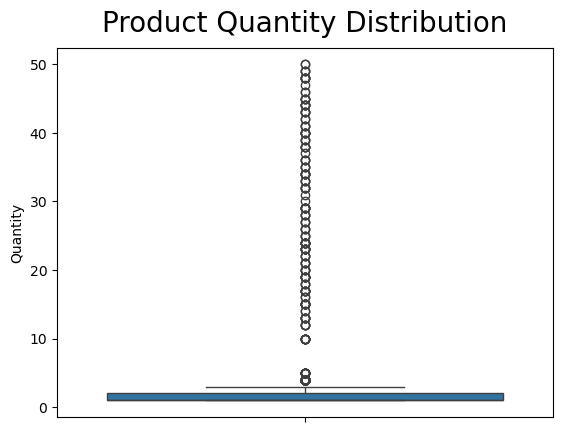

In [56]:
g = sns.boxplot(y = "quantity", data = trans_df)
g.set_title("Product Quantity Distribution", fontsize = 20, y = 1.02)
g.set_ylabel("Quantity")
plt.show()

In [57]:
trans_df["quantity"].fillna(trans_df["quantity"].median(), inplace = True)

I used the **median** because the quantity data is **skewed and contains extreme values**, such as 50. The median is less affected by these outliers than the mean.


In [58]:
trans_df["quantity"] = trans_df["quantity"].astype("int64")

In [59]:
trans_df["price"].describe()

count   31,673
mean       622
std        665
min         17
25%        180
50%        402
75%        877
max     21,372
Name: price, dtype: float64

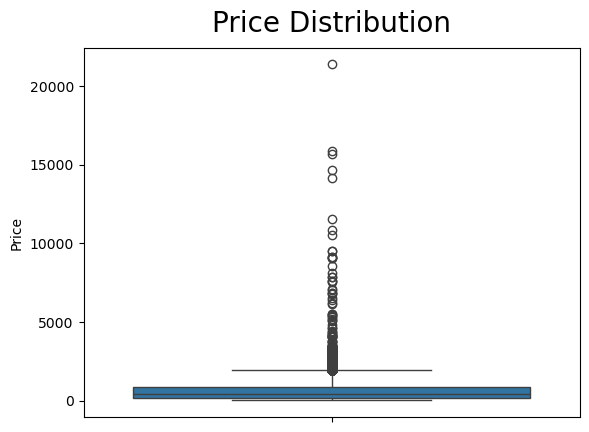

In [60]:
g = sns.boxplot(y = "price", data = trans_df)
g.set_title("Price Distribution", fontsize = 20, y = 1.02)
g.set_ylabel("Price")
plt.show()

In [61]:
trans_df["price"].fillna(trans_df["price"].median(), inplace = True)

In [62]:
trans_df['discount_applied'].describe()

count   31,684
mean         5
std          9
min          0
25%          0
50%          0
75%         10
max         30
Name: discount_applied, dtype: float64

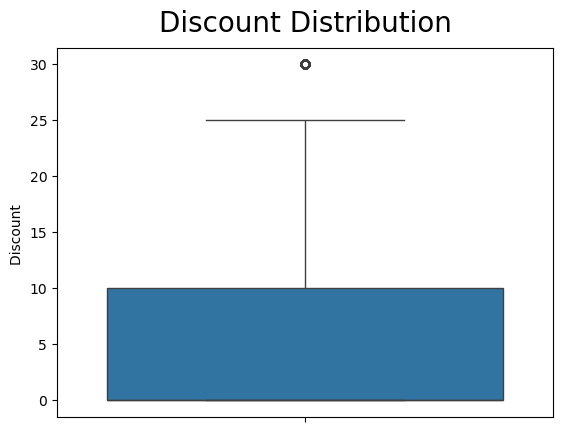

In [63]:
g = sns.boxplot(y = "discount_applied", data = trans_df)
g.set_title("Discount Distribution", fontsize = 20, y = 1.02)
g.set_ylabel("Discount ")
plt.show()

In [64]:
# I will be replacing NANs with 0 because it means there was no discount and 0 is actually the mean.
trans_df["discount_applied"].fillna(trans_df["discount_applied"].median(), inplace = True)

In [65]:
trans_df["discount_applied"] = trans_df["discount_applied"].astype("int64")

In [66]:
trans_df.isna().sum()

transaction_id        0
customer_id           0
product_name        678
product_category     19
quantity              0
price                 0
transaction_date      0
store_location      644
payment_method      660
discount_applied      0
dtype: int64

In [67]:
trans_df["store_location"].unique()

array(['Houston, TX', 'Online', 'Atlanta, GA', 'Boston, MA', 'Denver, CO',
       'Miami, FL', 'Chicago, IL', 'Seattle, WA', 'New York, NY',
       'San Francisco, CA', 'Los Angeles, CA', nan], dtype=object)

In [68]:
trans_df["store_location"].value_counts()

store_location
Online               16108
Houston, TX           1630
Miami, FL             1587
San Francisco, CA     1579
Atlanta, GA           1563
New York, NY          1562
Chicago, IL           1559
Seattle, WA           1536
Denver, CO            1529
Boston, MA            1528
Los Angeles, CA       1470
Name: count, dtype: int64

In [69]:
trans_df.dropna(subset = ["store_location"], inplace = True)

In [70]:
trans_df.dropna(subset = ["payment_method"], inplace = True)

In [71]:
trans_df.dropna(subset = ['product_category'], inplace = True)

In [72]:
trans_df.dropna(subset = ['product_name'], inplace = True)

### Missing Value Treatment

Missing values were handled based on the variable type and reliability of the available data. **Price, Quantity, and Discount Applied** were filled using the **median** because these numerical variables contained outliers.

For **Product Name**, missing records were dropped. For **Product Category**, existing product names were mapped to their corresponding categories. Only 19 records remained unmatched and were dropped.

Missing **Store Location** and **Payment Method** records were also dropped because they were relatively few and could not be reliably determined.


In [73]:
trans_df["transaction_date"] = pd.to_datetime(trans_df["transaction_date"], errors = "coerce")

In [74]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4699 entries, 1 to 4999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        4699 non-null   object
 1   age                4699 non-null   int64 
 2   gender             4699 non-null   object
 3   city               4699 non-null   object
 4   state              4699 non-null   object
 5   preferred_channel  4699 non-null   object
dtypes: int64(1), object(5)
memory usage: 386.0+ KB


In [75]:
cus_df.duplicated().sum()

0

In [76]:
trans_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30344 entries, 0 to 32294
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    30344 non-null  object        
 1   customer_id       30344 non-null  object        
 2   product_name      30344 non-null  object        
 3   product_category  30344 non-null  object        
 4   quantity          30344 non-null  int64         
 5   price             30344 non-null  float64       
 6   transaction_date  30344 non-null  datetime64[ns]
 7   store_location    30344 non-null  object        
 8   payment_method    30344 non-null  object        
 9   discount_applied  30344 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 2.5+ MB


In [77]:
trans_df.duplicated().sum()

0

In [78]:
df = trans_df.merge(cus_df, on = "customer_id", how = "left")

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30344 entries, 0 to 30343
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_id     30344 non-null  object        
 1   customer_id        30344 non-null  object        
 2   product_name       30344 non-null  object        
 3   product_category   30344 non-null  object        
 4   quantity           30344 non-null  int64         
 5   price              30344 non-null  float64       
 6   transaction_date   30344 non-null  datetime64[ns]
 7   store_location     30344 non-null  object        
 8   payment_method     30344 non-null  object        
 9   discount_applied   30344 non-null  int64         
 10  age                28575 non-null  float64       
 11  gender             28575 non-null  object        
 12  city               28575 non-null  object        
 13  state              28575 non-null  object        
 14  prefer

In [80]:
df.isna().sum()

transaction_id          0
customer_id             0
product_name            0
product_category        0
quantity                0
price                   0
transaction_date        0
store_location          0
payment_method          0
discount_applied        0
age                  1769
gender               1769
city                 1769
state                1769
preferred_channel    1769
dtype: int64

In [81]:
# Investigating why we are missing values since the both dataset were both cleaned before merging.
df[df['gender'].apply(lambda x: isinstance(x, (int, float)))][
    ['age', 'gender', 'city', 'state', 'preferred_channel']
].head()

,age,gender,city,state,preferred_channel
2,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN,NaN
28,NaN,NaN,NaN,NaN,NaN
47,NaN,NaN,NaN,NaN,NaN
49,NaN,NaN,NaN,NaN,NaN


In [82]:
df = df.dropna(subset =['age', 'gender', 'city', 'state', 'preferred_channel'])

In [83]:
df[['age', 'gender', 'city', 'state', 'preferred_channel']].isna().sum()

age                  0
gender               0
city                 0
state                0
preferred_channel    0
dtype: int64

Rows with missing customer information were removed because they represented only 5.5% of the dataset. Rather than assigning the same values to a large number of records, which could introduce bias and affect the reliability of the analysis, the incomplete records were excluded. This ensured that the remaining data was based on actual available information and supported more trustworthy business insights.

In [84]:
df.duplicated().sum()

0

In [85]:
df["age"].unique()

array([33., 18., 40., 26., 31., 45., 22., 44., 38., 70., 35., 23., 53.,
       37., 25., 32., 28., 41., 50., 30., 47., 49., 46., 54., 27., 73.,
       48., 34., 43., 19., 57., 36., 51., 42., 21., 52., 24., 68., 39.,
       29., 56., 58., 20., 65., 55., 59., 63., 60., 64., 67., 66., 61.,
       62., 71., 72.])

In [86]:
df["state"].unique()

array(['Florida', 'Texas', 'Pennsylvania', 'California', 'Arizona',
       'Washington', 'Illinois', 'Ohio', 'Georgia', 'New Jersey',
       'Michigan', 'New York', 'Virginia', 'North Carolina',
       'Massachusetts'], dtype=object)

In [87]:
df["payment_method"].unique()

array(['Credit Card', 'Gift Card', 'Debit Card', 'Apple Pay', 'Cash',
       'PayPal', 'Google Pay'], dtype=object)

In [88]:
# Select numerical columns
num_cols = df.select_dtypes(include = 'number').columns
num_cols

Index(['quantity', 'price', 'discount_applied', 'age'], dtype='object')

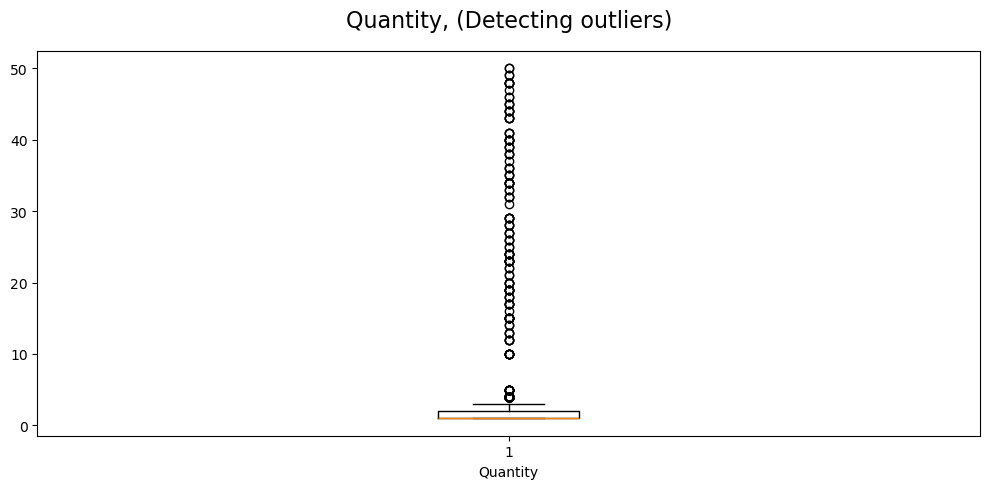

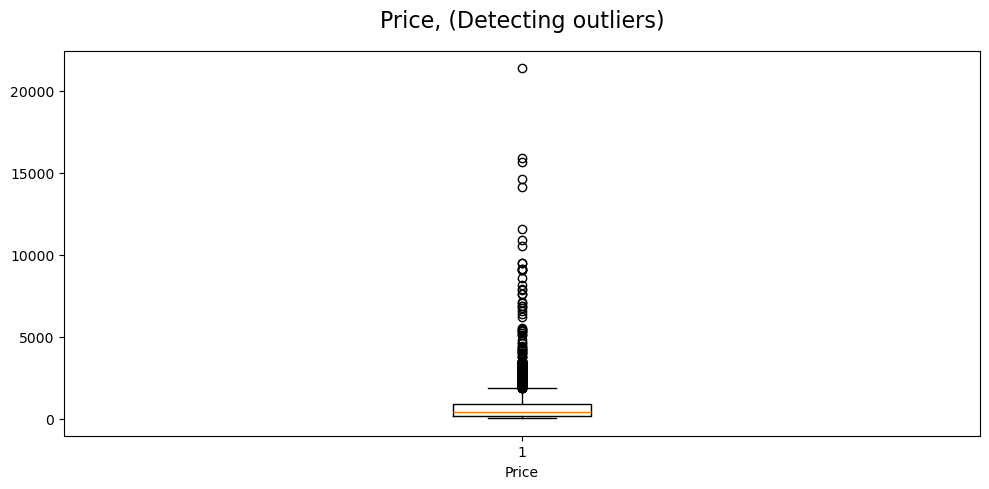

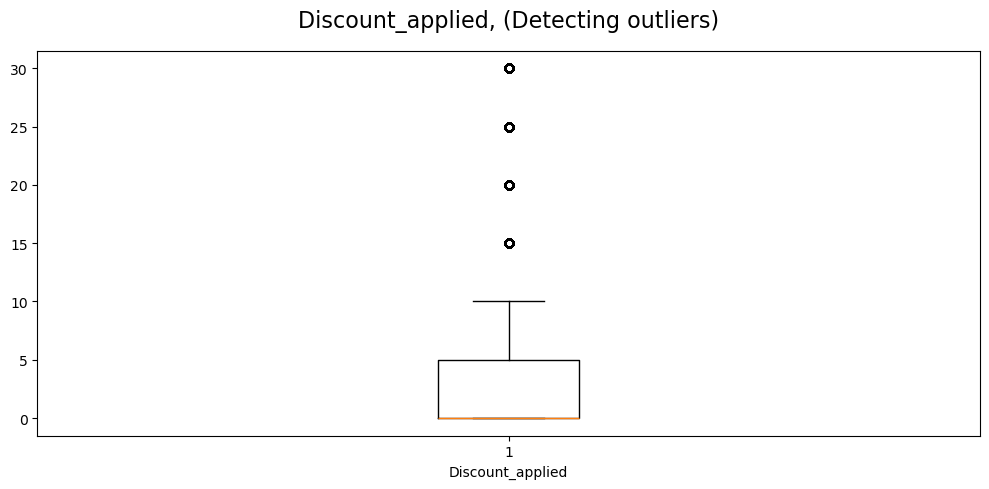

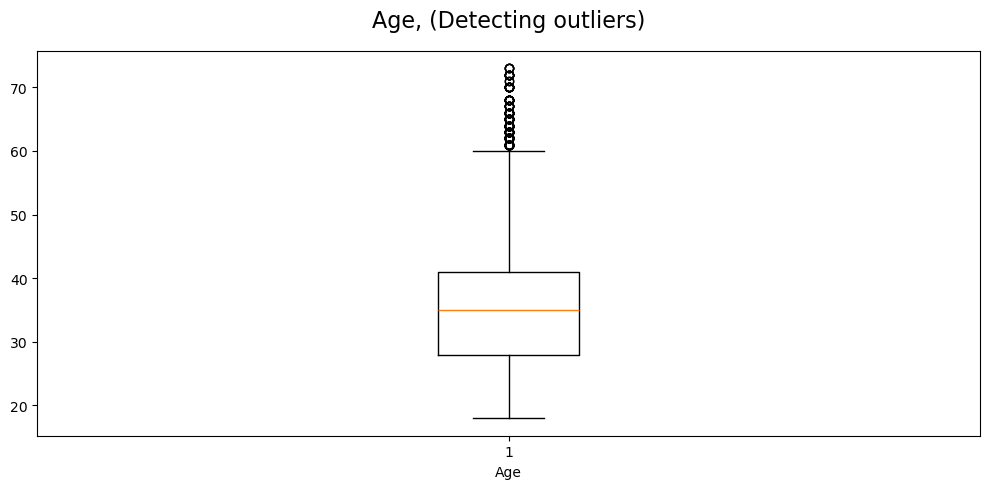

In [89]:
# Checking for outliers
for col in num_cols:
    plt.figure(figsize = (10, 5))
    plt.boxplot(x = df[col])
    plt.title(f'{col.capitalize()}, (Detecting outliers)', fontsize = 16, y = 1.04)
    plt.xlabel(col.capitalize())
    plt.tight_layout()
    plt.show()

In [90]:
df[['quantity', 'price', 'age', 'discount_applied']].describe()

,quantity,price,age,discount_applied
count,"28,575","28,575","28,575","28,575"
mean,1,618,35,5
std,2,667,10,9
min,1,17,18,0
25%,1,182,28,0
50%,1,402,35,0
75%,2,865,41,5
max,50,"21,372",73,30


In [91]:
for col in num_cols:
    df[col] = winsorize(df[col], limits = [0.05, 0.05])

Outlier Analysis: The descriptive statistics and boxplots revealed extreme values in Quantity, Price, and Age. For example, Quantity reaches a maximum of 50, while Price reaches 21,371.65. However, these observations were investigated and confirmed to represent legitimate values in the dataset rather than data-entry errors. Consequently, the outliers were retained to preserve the original characteristics of the data. The Discount Applied variable showed comparatively fewer extreme observations, with values ranging from 0 to 30.

In [92]:
df["revenue"] = df["quantity"] * df["price"]

In [93]:
df["year"] = df["transaction_date"].dt.year

In [94]:
df["month"] = df["transaction_date"].dt.month_name()

In [95]:
df["month"].unique()

array(['December', 'April', 'March', 'August', 'October', 'February',
       'June', 'July', 'November', 'January', 'September', 'May'],
      dtype=object)

In [96]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]
df["month"] = pd.Categorical(df["month"], categories = month_order, ordered = True)

In [97]:
df["quarter"] = df["transaction_date"].dt.quarter
df["quarter"] = "Q" + df["quarter"].astype(str)

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28575 entries, 0 to 30343
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_id     28575 non-null  object        
 1   customer_id        28575 non-null  object        
 2   product_name       28575 non-null  object        
 3   product_category   28575 non-null  object        
 4   quantity           28575 non-null  int64         
 5   price              28575 non-null  float64       
 6   transaction_date   28575 non-null  datetime64[ns]
 7   store_location     28575 non-null  object        
 8   payment_method     28575 non-null  object        
 9   discount_applied   28575 non-null  int64         
 10  age                28575 non-null  float64       
 11  gender             28575 non-null  object        
 12  city               28575 non-null  object        
 13  state              28575 non-null  object        
 14  preferred_c

# EDA

DESCRIPTIVE  STATISTICS

In [99]:
# Select numerical columns
num_cols = df.select_dtypes(include = 'number').columns
num_cols = [col for col in num_cols if col != 'year']
num_cols

['quantity', 'price', 'discount_applied', 'age', 'revenue']

In [100]:
summary = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Mode': [df[col].mode().iloc[0] for col in num_cols],
    'Standard Deviation': df[num_cols].std()
}, index = num_cols)

summary

,Mean,Median,Mode,Standard Deviation
quantity,1,1,1,0
price,590,402,60,525
discount_applied,5,0,0,9
age,35,35,35,9
revenue,742,473,"1,894",743


Insight: The average quantity purchased is about 1, and most customers purchase 1 item, showing that customers generally make small purchases. The average price is 590, but the median price is lower at 401, suggesting that some expensive products are increasing the average. Most transactions have no discount, as both the median and mode are 0, although some customers receive higher discounts. The average customer age is about 35 years, with most customers being around this age. Coming from the price column, where some product are increasing the average, it does the same to the revenue.

TIME SERIES ANALYSIS

In [101]:
df["revenue"]

0       140
1       340
3        92
4       985
5       216
         ..
30339   222
30340   402
30341   538
30342   231
30343   910
Name: revenue, Length: 28575, dtype: float64

In [102]:
yearly_sales = df.groupby("year")["revenue"].sum()
yearly_sales

year
2020     692,785
2021   2,241,228
2022   4,004,487
2023   5,777,406
2024   7,466,081
2025   1,031,550
Name: revenue, dtype: float64

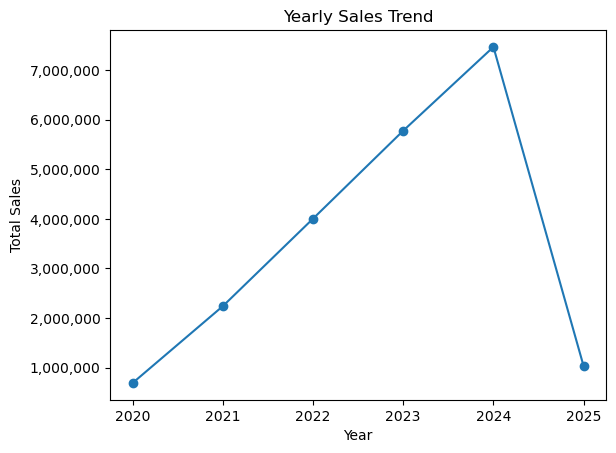

In [103]:
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.title('Yearly Sales Trend')
# Display full values on Y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)
plt.show()

In [104]:
monthly_sales = df.groupby("month", observed = True)["revenue"].sum()
monthly_sales

month
January     1,652,795
February    1,546,277
March       1,155,325
April       1,167,100
May         1,292,144
June        1,253,763
July        2,011,613
August      2,278,695
September   1,401,391
October     1,487,173
November    2,900,460
December    3,066,801
Name: revenue, dtype: float64

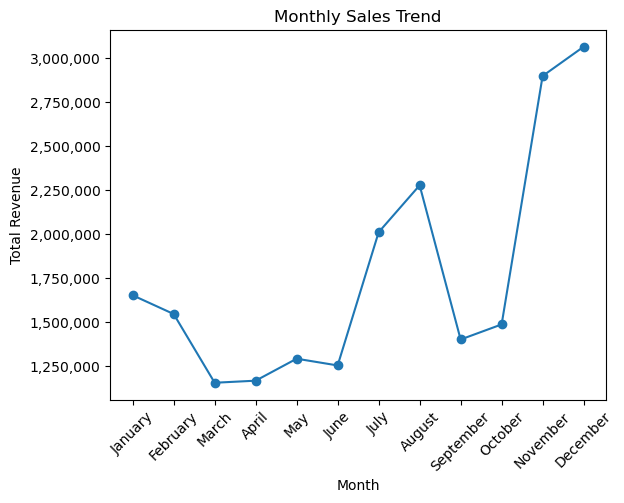

In [105]:
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
# Display full values on Y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)
plt.show()

In [106]:
quarterly_sales = df.groupby("quarter", observed = True)["revenue"].sum()
quarterly_sales

quarter
Q1   4,354,397
Q2   3,713,007
Q3   5,691,699
Q4   7,454,433
Name: revenue, dtype: float64

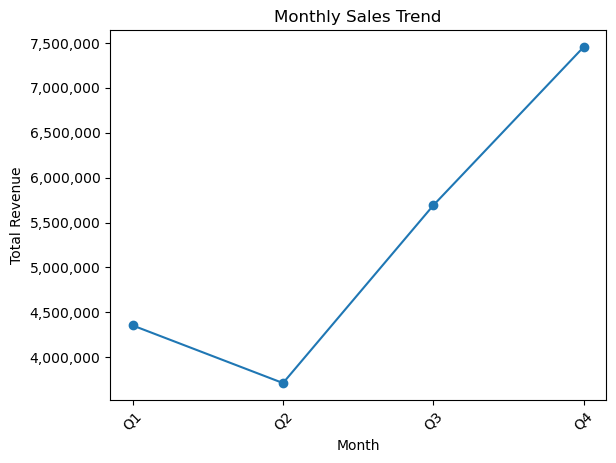

In [107]:
plt.plot(quarterly_sales.index, quarterly_sales.values, marker="o")

plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
# Display full values on Y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)
plt.show()

### Insight from Sales Trend

**Yearly:** Sales increased steadily from **692,785 in 2020** to **7,466,081 in 2024**, showing strong year-on-year growth. However, sales decreased to **1,031,550 in 2025**. This sharp decrease should be investigated further to determine whether it is due to lower sales or because the 2025 dataset does not cover the full year.

**Monthly:** Sales increased from **January to August**, followed by a decline in **September and October**. Sales then increased again in **November**. Sales were highest in **December (3,066,801)** and **November (2,900,460)**, while the lowest sales occurred in **March (1,155,325)**. Sales generally increased toward the end of the year, with a noticeable peak in **November and December**.

**Quarterly:** Revenue was highest in **Q4 (7,454,433)** and lowest in **Q2 (3,713,007)**. Revenue increased strongly in the second half of the year, with **Q3 and Q4** showing better performance than Q1 and Q2.

**Overall insight:** The fourth quarter generated the **highest sales**, suggesting that sales tend to be stronger toward the end of the year. This may indicate a possible seasonal pattern and could help the business plan inventory, marketing, and promotions for the final quarter.


CUSTOMER DEMOGRAPHICS

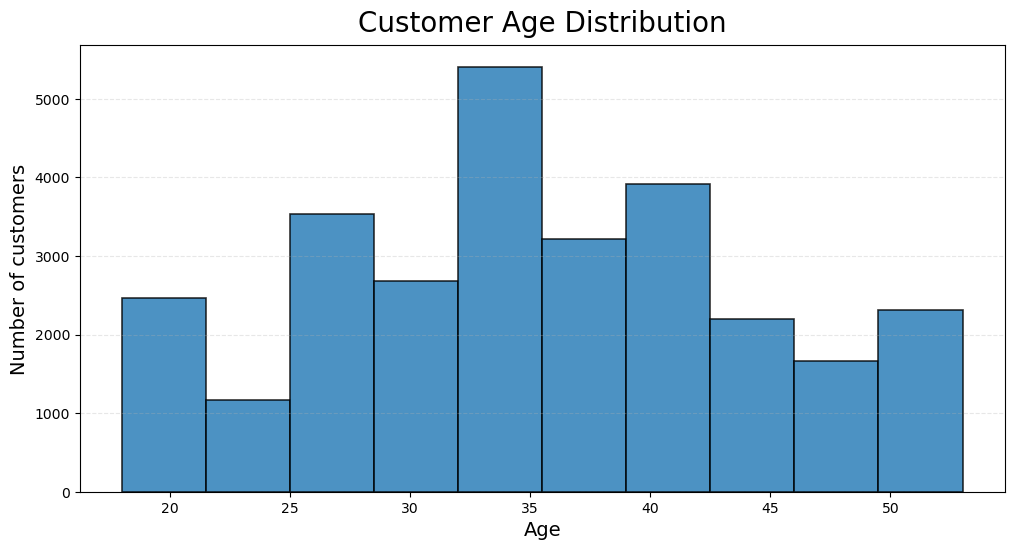

In [108]:
plt.figure(figsize = (10, 5))
plt.hist(df["age"], bins = 10, alpha = 0.8, edgecolor = "black", linewidth = 1.2)
plt.tight_layout()
plt.title("Customer Age Distribution", fontsize = 20, pad = 10)
plt.xlabel("Age", fontsize = 14)
plt.ylabel("Number of customers", fontsize = 14)
plt.grid(axis = "y", linestyle = "--", alpha = 0.3)
plt.show()

### Observation

The age distribution shows that most customers are around **35 years old**, indicating that the business has a strong customer base within the adult age range.


In [109]:
gender_counts = df["gender"].value_counts()

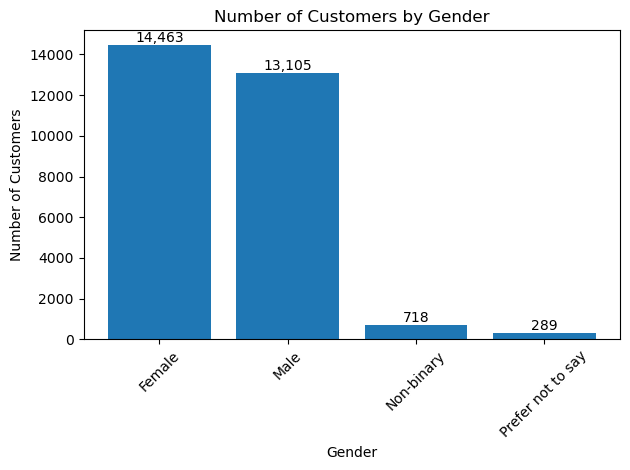

In [110]:
bars = plt.bar(gender_counts.index, gender_counts.values)
for bar in bars:
    value = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,
        value, f"{int(value):,}", ha = "center", va = "bottom")
plt.title("Number of Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

Female customers make up the largest gender group, with **14,463 customers**, followed by males with **13,105 customers**. Non-binary, Unknown, and Prefer not to say customers represent relatively smaller groups.


In [126]:
bins = [0, 29, 59, 100]

labels = [
    "Young Adult",
    "Adult",
    "Older Adult"
]
df["age_group"] = pd.cut(df["age"], bins = bins, labels = labels, include_lowest = True)

In [127]:
age_group_counts = df["age_group"].value_counts()

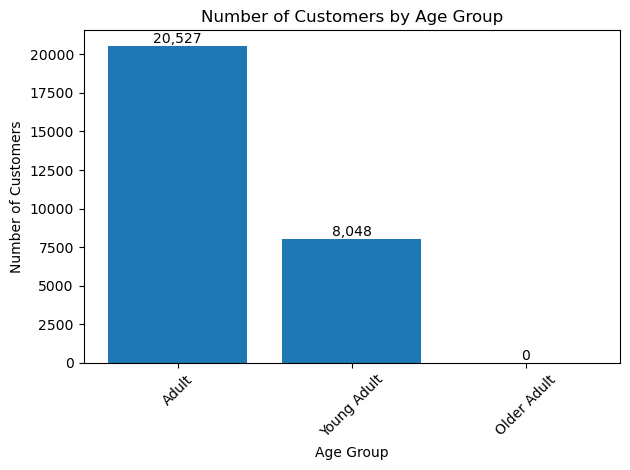

In [128]:
bars = plt.bar(age_group_counts.index, age_group_counts.values)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{int(value):,}",
        ha="center",
        va="bottom"
    )

plt.title("Number of Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The **Adult group has the highest number of customers, with 20,575 records**, followed by Young Adults with 8,048 records. No customers were recorded in the Older Adult group, showing that the customer base is mainly concentrated among younger and middle-aged customers.


In [129]:
# Revenue by Gender
gender_revenue = df.groupby("gender")["revenue"].sum().sort_values(ascending=False)
gender_revenue

gender
Female              10,793,208
Male                 9,662,962
Non-binary             546,167
Prefer not to say      211,200
Name: revenue, dtype: float64

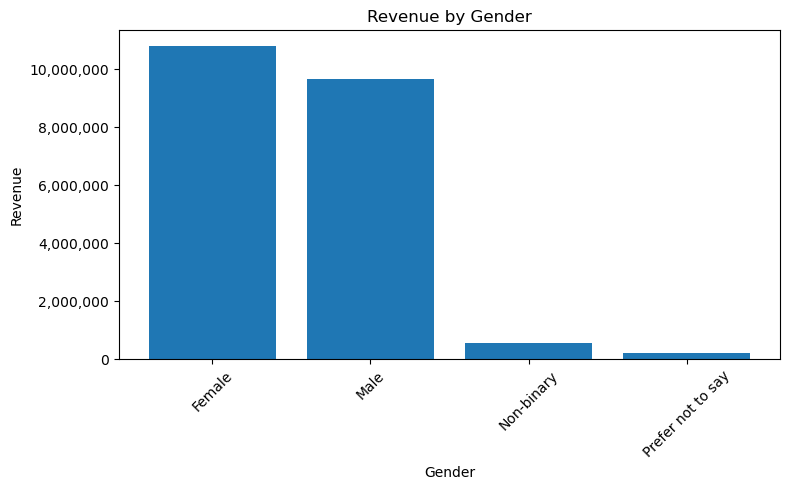

In [115]:
plt.figure(figsize=(8, 5))
plt.bar(gender_revenue.index, gender_revenue.values)

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

# Display full values on Y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

plt.tight_layout()
plt.show()

### Insight from Revenue by Gender

**Gender:** Revenue was highest among **Female customers (10,793,208)**, followed by **Male customers (9,662,962)**. **Non-binary customers** and those who **preferred not to say** contributed a smaller share of total revenue.


In [116]:
# Revenue by Age group
age_group_revenue = df.groupby("age_group")["revenue"].sum().sort_values(ascending=False)
age_group_revenue

age_group
Adult         15,123,336
Young Adult    6,090,201
Older Adult            0
Name: revenue, dtype: float64

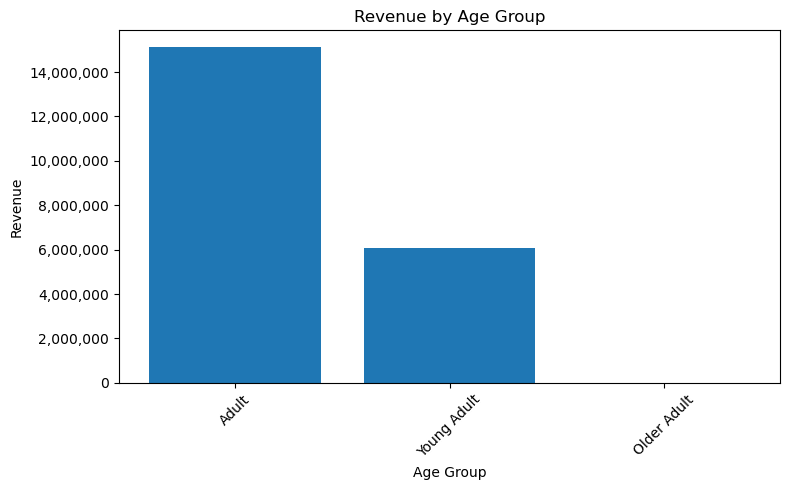

In [117]:
plt.figure(figsize=(8, 5))
plt.bar(age_group_revenue.index, age_group_revenue.values)

plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

# Display full values on Y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

plt.tight_layout()
plt.show()

### Insight from Revenue by Age Group

**Age Group:** Revenue was highest among **Adults (15,123,336)**, while **Young Adults generated 6,090,201**. **Older Adults recorded no revenue** in the dataset.

In [118]:
# Revenue by Age Group and Gender
age_gender_revenue = (
    df.groupby(["age_group", "gender"], observed=True)["revenue"].sum().unstack())
age_gender_revenue

gender,Female,Male,Non-binary,Prefer not to say
age_group,,,,
Young Adult,"3,113,165","2,748,285","160,172","68,580"
Adult,"7,680,044","6,914,677","385,995","142,620"


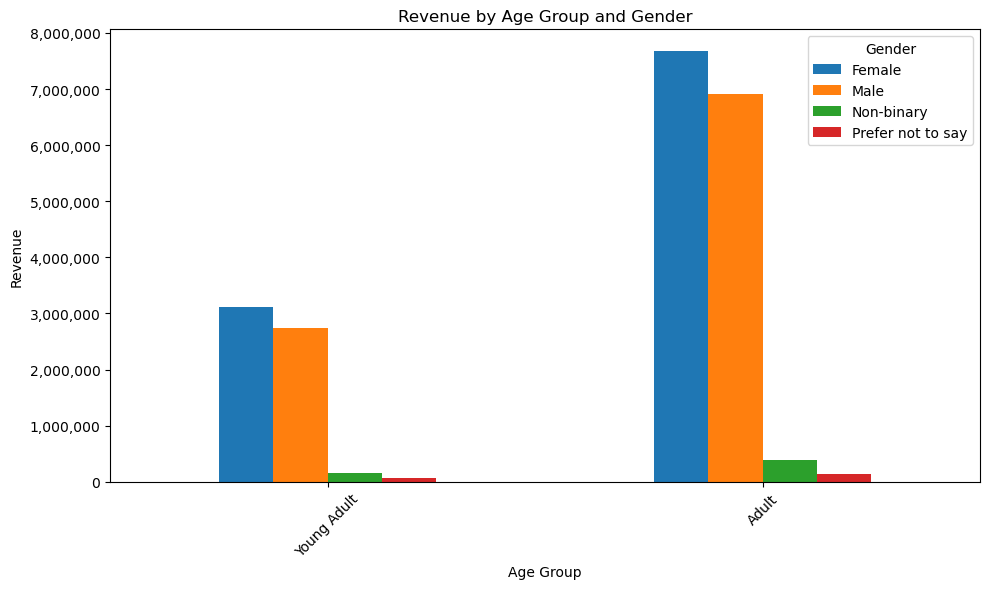

In [119]:
# Plot
ax = age_gender_revenue.plot(kind = "bar", figsize = (10, 6))

plt.title("Revenue by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Gender")

# Display full revenue values on Y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

### Insight from Revenue by Age Group and Gender

**Age & Gender:** **Adult females generated the highest revenue (7,680,044)**, followed by **adult males (6,914,677)**. Among Young Adults, females also generated more revenue than males. Overall, **Adults contributed the largest share of revenue across all gender groups**.

# PRODUCT ANALYSIS

In [120]:
top_10_product = df.groupby("product_name")["quantity"].sum().sort_values(ascending = False).head(10)
top_10_product

product_name
iPhone 13             1061
OnePlus 10            1036
Xiaomi Mi 12          1027
Amazon Echo           1026
Google Nest           1023
Philips Hue Lights    1004
Google Pixel 6         996
Smart Thermostat       992
Ring Doorbell          942
Bed Frame              938
Name: quantity, dtype: int64

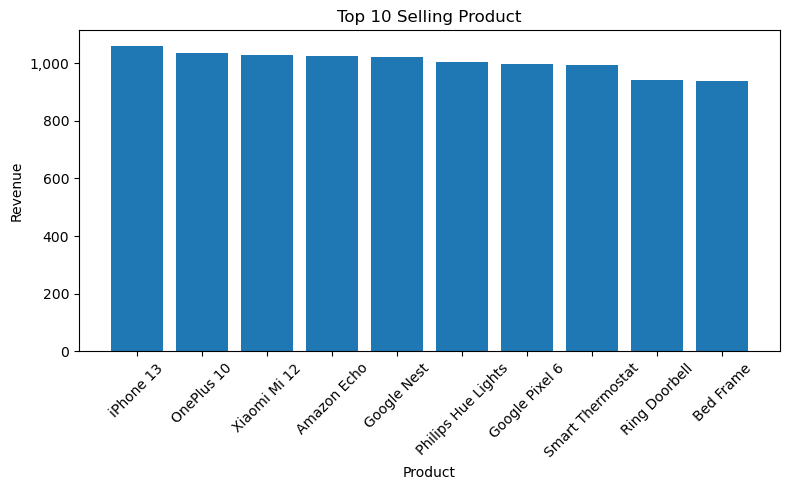

In [121]:
plt.figure(figsize=(8, 5))
plt.bar(top_10_product.index, top_10_product.values)

plt.title("Top 10 Selling Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

# Display full values on Y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

### Insight from Product Quantity

**Product:** **iPhone 13 had the highest quantity sold (1,061 units)**, followed by **OnePlus 10 (1,036)** and **Xiaomi Mi 12 (1,027)**. **Bed Frame had the lowest quantity among the top 10 products (938 units)**.


In [122]:
# Revenue by product category
category_revenue = df.groupby("product_category")["revenue"].sum().sort_values(ascending = False)
category_revenue

product_category
Furniture                  4,735,126
Smartphones                3,993,861
Laptops                    3,039,839
Kitchen Appliances         2,348,112
TVs                        2,139,944
Desktop Computers            957,374
Smart Home Devices           881,876
Gaming Consoles              856,769
Home Decor                   718,173
Audio Equipment              597,736
Tablets                      377,000
Small Kitchen Appliances     192,637
Cookware                     174,934
Bedding                      134,119
Computer Accessories          66,036
Name: revenue, dtype: float64

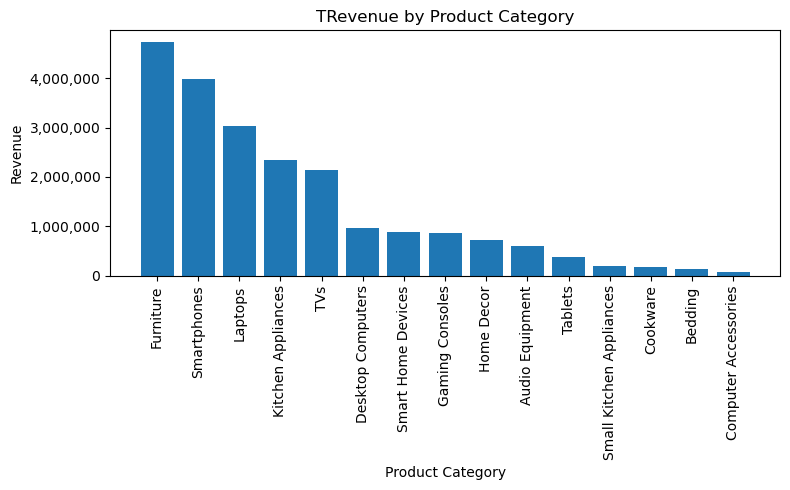

In [123]:
plt.figure(figsize=(8, 5))
plt.bar(category_revenue.index, category_revenue.values)

plt.title("TRevenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation = 90)

# Display full values on Y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

### Insight from Revenue by Product Category

**Product Category:** **Furniture generated the highest revenue (4,735,126)**, followed by **Smartphones (3,993,861)** and **Laptops (3,039,839)**. **Computer Accessories generated the lowest revenue (66,036)**. Overall, revenue was concentrated in **Furniture, Smartphones, and Laptops**.


In [124]:
# Do the product that sells the most generates the most revenue
# Total quantity sold and total revenue for each product
product_analysis = (
    df.groupby('product_name')
      .agg(
          Total_Quantity_Sold = ('quantity', 'sum'),
          Total_Revenue = ('revenue', 'sum')
      )
      .sort_values('Total_Quantity_Sold', ascending = False)
)

product_analysis.head(10)

,Total_Quantity_Sold,Total_Revenue
product_name,,
iPhone 13,1061,"847,855"
OnePlus 10,1036,"824,224"
Xiaomi Mi 12,1027,"811,959"
Amazon Echo,1026,"183,022"
Google Nest,1023,"184,305"
Philips Hue Lights,1004,"176,743"
Google Pixel 6,996,"782,190"
Smart Thermostat,992,"172,477"
Ring Doorbell,942,"165,328"


### Insight from Product Performance

**Product:** **iPhone 13 had the highest quantity sold (1,061 units)** and generated **847,855 in revenue**. However, **Bed Frame generated the highest revenue (1,023,041)** despite having only **938 units sold**, indicating a higher revenue per unit.


In [130]:
df[num_cols].corr()

,quantity,price,discount_applied,age,revenue
quantity,1,0,0,-0,0
price,0,1,0,0,1
discount_applied,0,0,1,-0,0
age,-0,0,-0,1,0
revenue,0,1,0,0,1


### Insight from Correlation Analysis

**Correlation:** The correlation matrix shows a **very strong positive relationship between price and revenue (1.00)**. The other variables **quantity, discount applied, and age** show little to no correlation with revenue.

**Key finding:** Revenue in this dataset appears to be driven mainly by **price**, rather than quantity, discount, or customer age.


### Conclusion

Overall, the business showed **strong sales growth from 2020 to 2024**, with the **fourth quarter generating the highest sales**. The customer base is mainly made up of **adults**, with adult females contributing the highest revenue. **Furniture was the highest-revenue category**, while the analysis also showed that the best-selling product by quantity does not necessarily generate the most revenue. The 2025 sales decline should also be investigated further.

### Recommendations

1. **Prepare for Q4 demand:** Increase inventory and marketing before November and December to take advantage of higher seasonal sales.

2. **Focus on high-revenue products:** Prioritize products and categories such as **Furniture** and other high-revenue items rather than focusing only on sales volume.

3. **Target adult customers:** Develop targeted promotions for the **adult customer segment**, particularly adult females, since they generate the highest revenue.

4. **Investigate the 2025 decline:** Determine whether the drop in 2025 is due to incomplete yearly data or an actual decrease in sales, and take corrective action if necessary.
